<a href="https://colab.research.google.com/github/TaranpreetSinghBhatia/ai-mlops-journey/blob/main/phase1_ml_foundations/02_data_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Data Loading, Cleaning & Exploration
**Goal:** Understand real-world data — messy, missing, needs work.
**Dataset:** Titanic passengers
**Skills:** pandas, EDA, handling missing values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading Titanic dataset directly form URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset Loaded!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
#What column do we have? what type?
print("Column info:")
print(df.dtypes)
print(f"\n Basic Stats:")
df.describe()

Column info:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

 Basic Stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Where is data missing?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("🔍 Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

🔍 Missing Values:
          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


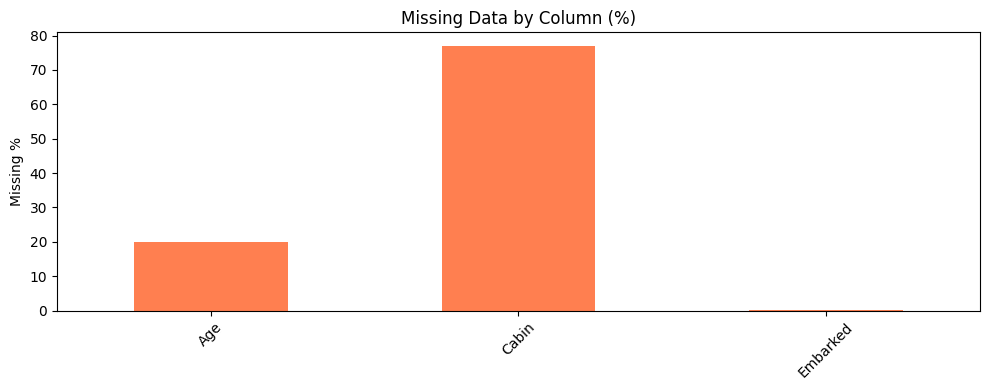

In [4]:
plt.figure(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='coral')
plt.title('Missing Data by Column (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df_clean = df.copy()

# 1. Fill missing Age with median age
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# 2. Fill missing Embarked with most common port
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Drop Cabin — too much missing (77%!)
df_clean.drop(columns=['Cabin'], inplace=True)

print(f"✅ Cleaning done!")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

✅ Cleaning done!
Missing values remaining: 0


/tmp/ipykernel_3250/4067063999.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipykernel_3250/4067063999.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

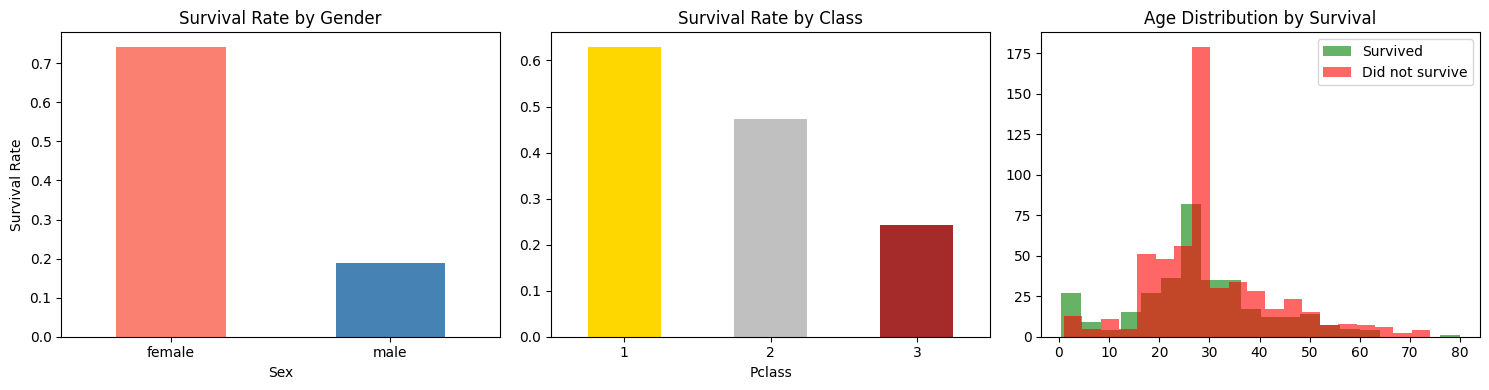

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by gender
df_clean.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=0)

# Survival by class
df_clean.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['gold', 'silver', 'brown'])
axes[1].set_title('Survival Rate by Class')
axes[1].tick_params(axis='x', rotation=0)

# Age distribution
axes[2].hist(df_clean[df_clean['Survived']==1]['Age'],
             alpha=0.6, label='Survived', color='green', bins=20)
axes[2].hist(df_clean[df_clean['Survived']==0]['Age'],
             alpha=0.6, label='Did not survive', color='red', bins=20)
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
print("=" * 45)
print("       TITANIC DATA INSIGHTS")
print("=" * 45)
print(f"Total passengers : {len(df_clean)}")
print(f"Survived         : {df_clean['Survived'].sum()} ({df_clean['Survived'].mean()*100:.1f}%)")
print(f"Women survival   : {df_clean[df_clean['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"Men survival     : {df_clean[df_clean['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"1st class surv.  : {df_clean[df_clean['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"3rd class surv.  : {df_clean[df_clean['Pclass']==3]['Survived'].mean()*100:.1f}%")
print("=" * 45)

       TITANIC DATA INSIGHTS
Total passengers : 891
Survived         : 342 (38.4%)
Women survival   : 74.2%
Men survival     : 18.9%
1st class surv.  : 63.0%
3rd class surv.  : 24.2%
